## [``dyce``](https://posita.github.io/dyce/) translation of one example from [``LordSembor/DnDice``](https://github.com/LordSembor/DnDice#examples)

Select ``Run All Cells`` from the ``Run`` menu above.

In [1]:
# Install additional requirements if necessary
import warnings

from dyce.lifecycle import ExperimentalWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        import dyce  # noqa: F401
    except (ImportError, ModuleNotFoundError):
        # See <https://jupyterlite.readthedocs.io/en/stable/howto/configure/simple_extensions.html#avoid-the-drift-of-versions-between-the-frontend-extension-and-the-python-package>
        requirements = ["dyce~=0.7.0"]
        try:
            import piplite  # pyrefly: ignore[missing-import] # ty: ignore[unresolved-import]

            await piplite.install(requirements, keep_going=True)
            # Work around <https://github.com/jupyterlite/jupyterlite/issues/838>
            from matplotlib import pyplot as plt

            plt.clf()
        except ImportError:
            import pip  # pyrefly: ignore[missing-import] # ty: ignore[unresolved-import]

            pip.main(["install", *requirements])

warnings.filterwarnings("ignore", category=ExperimentalWarning)

In [2]:
from dyce import H, HResult, expand

single_attack = 2 @ H(6) + 5


def gwf(result: HResult[int]) -> H[int] | int:
    return result.h if result.outcome in (1, 2) else result.outcome


great_weapon_fighting = 2 @ expand(gwf, H(6)) + 5

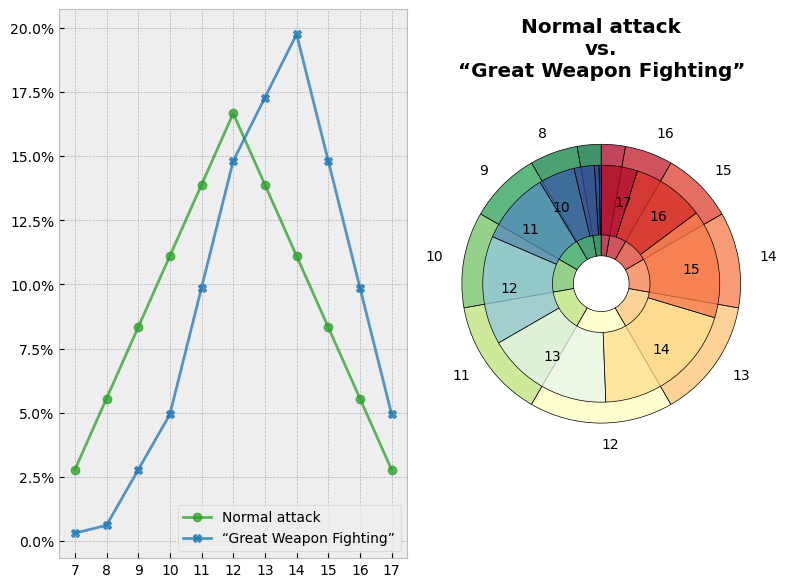

In [3]:
from matplotlib import pyplot as plt
from matplotlib import style

from dyce.viz import plot_burst, plot_line

plt.figure().set_size_inches(8, 6)
style.use("bmh")
label_sa = "Normal attack"
label_gwf = "\u201cGreat Weapon Fighting\u201d"

ax_plot = plt.subplot2grid((1, 2), (0, 0))
plot_line(
    single_attack, great_weapon_fighting, labels=[label_sa, label_gwf], ax=ax_plot
)
ax_plot.lines[0].set_color("tab:green")
ax_plot.lines[1].set_color("tab:blue")
ax_plot.legend()

ax_burst = plt.subplot2grid((1, 2), (0, 1))
plot_burst(
    great_weapon_fighting,
    single_attack,
    cmap="RdYlBu_r",
    compare_cmap="RdYlGn_r",
    title=f"{label_sa}\nvs.\n{label_gwf}",
    ax=ax_burst,
)
plt.tight_layout()